# SemanticKITTI Data Exploration

This notebook explores the three core data files in the SemanticKITTI dataset:

- **`.bin`** — Velodyne LiDAR point clouds (x, y, z, intensity)
- **`.label`** — Per-point semantic + instance labels
- **`poses.txt`** — Per-frame ego-vehicle poses (SE(3) transformations)

We examine each format individually, then explore relationships between them.


## 1. Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

# Base path to dataset
DATA_ROOT = os.path.join(os.path.dirname(os.getcwd()), "dataset", "sequences")
SEQ = "00"  # Primary sequence to explore

# Helper to load a .bin file
def load_bin(path):
    return np.fromfile(path, dtype=np.float32).reshape(-1, 4)

# Helper to load a .label file
def load_label(path):
    raw = np.fromfile(path, dtype=np.uint32)
    sem = raw & 0xFFFF        # lower 16 bits: semantic class
    inst = raw >> 16          # upper 16 bits: instance ID
    return sem, inst

# Helper to load poses.txt
def load_poses(path):
    poses = []
    with open(path, "r") as f:
        for line in f:
            values = np.array([float(x) for x in line.strip().split()])
            T = np.eye(4)
            T[:3, :] = values.reshape(3, 4)
            poses.append(T)
    return poses

# Helper to load calib.txt (camera projections P0-P3 and Tr: velo-to-cam)
def load_calib(path):
    data = {}
    with open(path, "r") as f:
        for line in f:
            key, _, value = line.partition(":")
            if value.strip():
                values = np.array([float(x) for x in value.strip().split()])
                if len(values) == 12:
                    M = np.eye(4)
                    M[:3, :] = values.reshape(3, 4)
                    data[key.strip()] = M
    return data

# Helper to load times.txt
def load_times(path):
    times = []
    with open(path, "r") as f:
        for line in f:
            times.append(float(line.strip()))
    return np.array(times)

# SemanticKITTI label mapping (ID -> name)
LABEL_NAMES = {
    0: "unlabeled", 1: "outlier", 10: "car", 11: "bicycle", 13: "bus",
    15: "motorcycle", 16: "on-rails", 18: "truck", 20: "other-vehicle",
    30: "person", 31: "bicyclist", 32: "motorcyclist", 40: "road",
    44: "parking", 48: "sidewalk", 49: "other-ground", 50: "building",
    51: "fence", 52: "other-structure", 60: "lane-marking", 70: "vegetation",
    71: "trunk", 72: "terrain", 80: "pole", 81: "traffic-sign",
    99: "other-object",
    252: "moving-car", 253: "moving-bicyclist", 254: "moving-person",
    255: "moving-motorcyclist", 256: "moving-on-rails", 257: "moving-bus",
    258: "moving-truck", 259: "moving-other-vehicle",
}

# SemanticKITTI official color map (source is BGR, converted to RGB here)
LABEL_COLORS = {
    0: (0, 0, 0), 1: (255, 0, 0), 10: (100, 150, 245), 11: (100, 230, 245),
    13: (100, 80, 250), 15: (30, 60, 150), 16: (0, 0, 255), 18: (80, 30, 180),
    20: (0, 0, 255), 30: (255, 30, 30), 31: (255, 40, 200),
    32: (150, 30, 90), 40: (255, 0, 255), 44: (255, 150, 255),
    48: (75, 0, 75), 49: (175, 0, 75), 50: (255, 200, 0),
    51: (255, 120, 50), 52: (255, 150, 0), 60: (150, 255, 170),
    70: (0, 175, 0), 71: (135, 60, 0), 72: (150, 240, 80),
    80: (255, 240, 150), 81: (255, 0, 0), 99: (50, 255, 255),
    252: (100, 150, 245), 253: (255, 40, 200), 254: (255, 30, 30),
    255: (150, 30, 90), 256: (0, 0, 255), 257: (100, 80, 250),
    258: (80, 30, 180), 259: (0, 0, 255),
}

# Thing classes (objects with instance labels)
THING_CLASSES = {10, 11, 13, 15, 16, 18, 20, 30, 31, 32,
                 252, 253, 254, 255, 256, 257, 258, 259}

# Learning map: maps raw semantic IDs to training class IDs (0-25)
LEARNING_MAP = {
    0: 0, 1: 0, 10: 1, 11: 2, 13: 5, 15: 3, 16: 5, 18: 4, 20: 5,
    30: 6, 31: 7, 32: 8, 40: 9, 44: 10, 48: 11, 49: 12, 50: 13,
    51: 14, 52: 0, 60: 9, 70: 15, 71: 16, 72: 17, 80: 18, 81: 19,
    99: 0, 252: 20, 253: 21, 254: 22, 255: 23, 256: 24, 257: 24,
    258: 25, 259: 24,
}

# Official dataset split
SPLIT = {
    "train": [0, 1, 2, 3, 4, 5, 6, 7, 9, 10],
    "valid": [8],
    "test": [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21],
}

# Expected class content (fraction of total points across full dataset)
CLASS_CONTENT = {
    0: 0.0189, 1: 0.0003, 10: 0.0408, 11: 0.0002, 13: 0.0000,
    15: 0.0004, 16: 0.0000, 18: 0.0021, 20: 0.0016, 30: 0.0002,
    31: 0.0000, 32: 0.0000, 40: 0.1987, 44: 0.0147, 48: 0.1439,
    49: 0.0039, 50: 0.1327, 51: 0.0724, 52: 0.0024, 60: 0.0000,
    70: 0.2668, 71: 0.0060, 72: 0.0781, 80: 0.0029, 81: 0.0006,
    99: 0.0099, 252: 0.0018, 253: 0.0001, 254: 0.0002, 255: 0.0000,
    256: 0.0000, 257: 0.0001, 258: 0.0001, 259: 0.0000,
}

print(f"Dataset root: {DATA_ROOT}")
print(f"Primary sequence: {SEQ}")
print(f"Train/Val/Test split: {len(SPLIT['train'])}/{len(SPLIT['valid'])}/{len(SPLIT['test'])} sequences")

Dataset root: /Users/ngovivietanh/Coding/LIDAR_Segmentation/dataset/sequences
Primary sequence: 00
Train/Val/Test split: 10/1/11 sequences


## 2. Velodyne Point Cloud (`.bin`)

Each `.bin` file contains a raw LiDAR scan as a flat array of `float32` values.  
Format: `N × 4` — columns are **(x, y, z, intensity)**.


### 2.1 Single Frame Inspection


In [2]:
# Load a single frame
bin_path = os.path.join(DATA_ROOT, SEQ, "velodyne", "000000.bin")
points = load_bin(bin_path)

print(f"File: {os.path.basename(bin_path)}")
print(f"File size: {os.path.getsize(bin_path) / 1e6:.2f} MB")
print(f"Shape: {points.shape}  (N_points x [x, y, z, intensity])")
print(f"Dtype: {points.dtype}")
print()

# Per-column statistics
col_names = ["x", "y", "z", "intensity"]
print(f"{'Column':<12} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10}")
print("-" * 55)
for i, name in enumerate(col_names):
    col = points[:, i]
    print(
        f"{name:<12} {col.min():>10.3f} {col.max():>10.3f} {col.mean():>10.3f} {col.std():>10.3f}"
    )

File: 000000.bin
File size: 1.99 MB
Shape: (124668, 4)  (N_points x [x, y, z, intensity])
Dtype: float32

Column              Min        Max       Mean        Std
-------------------------------------------------------
x               -78.087     77.967     -1.435     13.874
y               -55.723     44.879      1.025      9.897
z               -11.557      2.825     -1.211      0.856
intensity         0.000      0.990      0.294      0.148


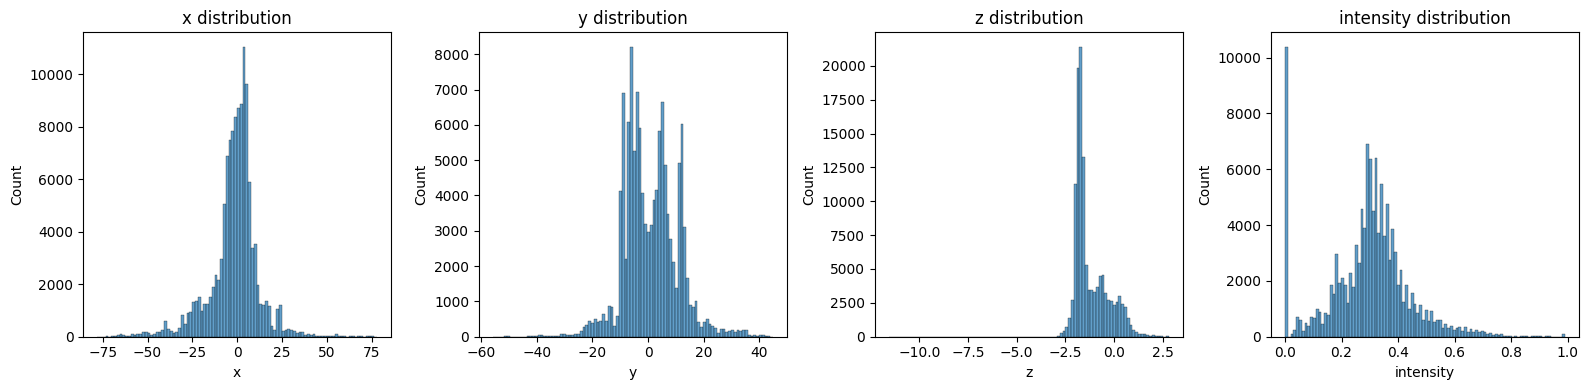

In [3]:
# Histograms of x, y, z, intensity
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (name, ax) in enumerate(zip(col_names, axes)):
    ax.hist(points[:, i], bins=100, alpha=0.7, edgecolor="black", linewidth=0.3)
    ax.set_title(f"{name} distribution")
    ax.set_xlabel(name)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

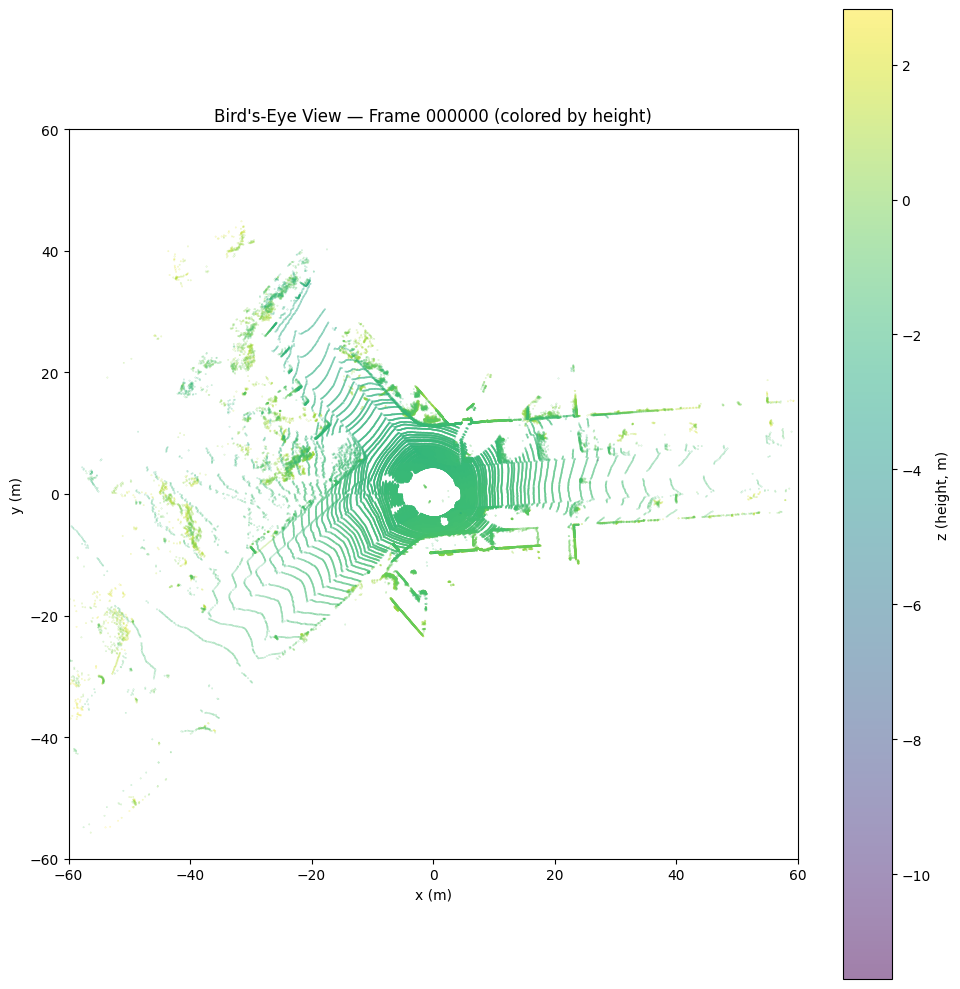

In [4]:
# Bird's-eye view (BEV): x vs y, colored by z height
fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter(
    points[:, 0], points[:, 1], c=points[:, 2], cmap="viridis", s=0.05, alpha=0.5
)
plt.colorbar(scatter, ax=ax, label="z (height, m)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Bird's-Eye View — Frame 000000 (colored by height)")
ax.set_aspect("equal")
ax.set_xlim(-60, 60)
ax.set_ylim(-60, 60)
plt.tight_layout()
plt.show()

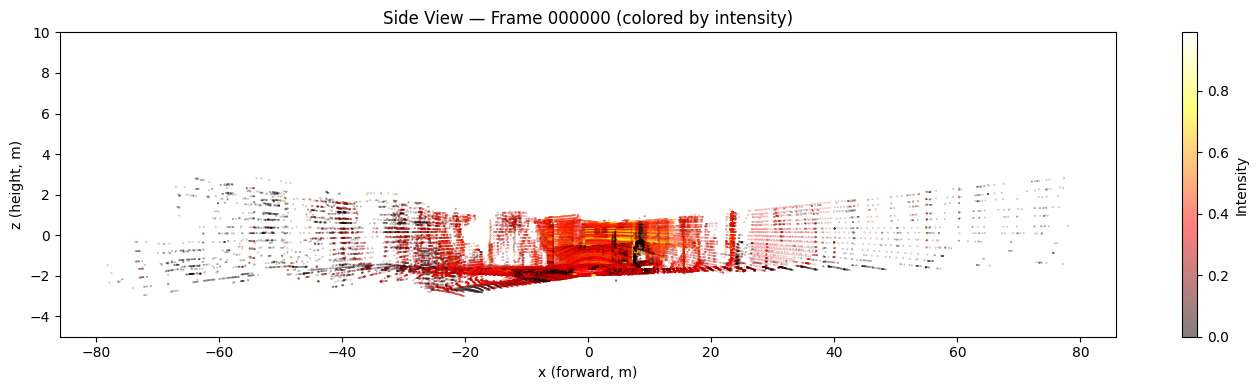

In [5]:
# Side view: x vs z (front view of the scene)
fig, ax = plt.subplots(figsize=(14, 4))
scatter = ax.scatter(
    points[:, 0], points[:, 2], c=points[:, 3], cmap="hot", s=0.05, alpha=0.5
)
plt.colorbar(scatter, ax=ax, label="Intensity")
ax.set_xlabel("x (forward, m)")
ax.set_ylabel("z (height, m)")
ax.set_title("Side View — Frame 000000 (colored by intensity)")
ax.set_ylim(-5, 10)
plt.tight_layout()
plt.show()

## 3. Semantic Labels (`.label`)

Each `.label` file stores one `uint32` per point. The lower 16 bits encode the **semantic class**, and the upper 16 bits encode the **instance ID** (nonzero only for "thing" classes like cars, people, etc.).


In [6]:
# Load label for the same frame
label_path = os.path.join(DATA_ROOT, SEQ, "labels", "000000.label")
sem, inst = load_label(label_path)

print(f"File: {os.path.basename(label_path)}")
print(f"File size: {os.path.getsize(label_path) / 1e6:.2f} MB")
print(f"Number of labels: {len(sem)}")
print(f"Number of points in .bin: {len(points)}")
print(f"Match: {len(sem) == len(points)}")
print()

# Raw uint32 decoding demonstration
raw = np.fromfile(label_path, dtype=np.uint32)
print("--- Decoding example (first 5 points) ---")
print(f"{'Raw uint32':<15} {'Binary (last 32 bits)':<35} {'Semantic':<12} {'Instance'}")
for i in range(5):
    print(f"{raw[i]:<15} {bin(raw[i]):<35} {sem[i]:<12} {inst[i]}")

File: 000000.label
File size: 0.50 MB
Number of labels: 124668
Number of points in .bin: 124668
Match: True

--- Decoding example (first 5 points) ---
Raw uint32      Binary (last 32 bits)               Semantic     Instance
0               0b0                                 0            0
0               0b0                                 0            0
0               0b0                                 0            0
0               0b0                                 0            0
0               0b0                                 0            0


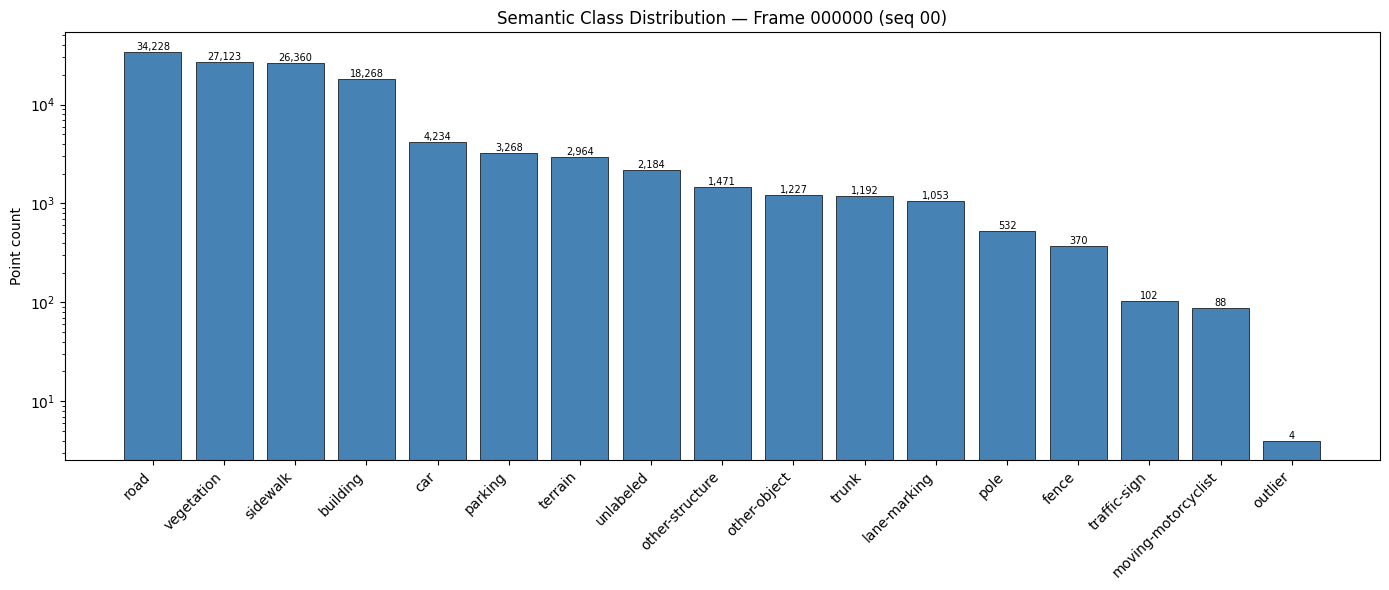


Class                   ID      Count        %
---------------------------------------------
road                    40     34,228   27.46%
vegetation              70     27,123   21.76%
sidewalk                48     26,360   21.14%
building                50     18,268   14.65%
car                     10      4,234    3.40%
parking                 44      3,268    2.62%
terrain                 72      2,964    2.38%
unlabeled                0      2,184    1.75%
other-structure         52      1,471    1.18%
other-object            99      1,227    0.98%
trunk                   71      1,192    0.96%
lane-marking            60      1,053    0.84%
pole                    80        532    0.43%
fence                   51        370    0.30%
traffic-sign            81        102    0.08%
moving-motorcyclist    255         88    0.07%
outlier                  1          4    0.00%


In [7]:
# Semantic class distribution
unique_sem, counts = np.unique(sem, return_counts=True)
sorted_idx = np.argsort(-counts)  # descending

fig, ax = plt.subplots(figsize=(14, 6))
names = [LABEL_NAMES.get(s, f"unknown({s})") for s in unique_sem[sorted_idx]]
bars = ax.bar(
    range(len(names)),
    counts[sorted_idx],
    color="steelblue",
    edgecolor="black",
    linewidth=0.5,
)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_ylabel("Point count")
ax.set_title(f"Semantic Class Distribution — Frame 000000 (seq {SEQ})")
ax.set_yscale("log")

# Annotate counts
for bar, count in zip(bars, counts[sorted_idx]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=7,
    )

plt.tight_layout()
plt.show()

# Print table
print(f"\n{'Class':<20} {'ID':>5} {'Count':>10} {'%':>8}")
print("-" * 45)
for i in sorted_idx:
    name = LABEL_NAMES.get(unique_sem[i], f"unknown({unique_sem[i]})")
    pct = counts[i] / len(sem) * 100
    print(f"{name:<20} {unique_sem[i]:>5} {counts[i]:>10,} {pct:>7.2f}%")

In [8]:
# Instance IDs per thing class
print("Instance counts per thing class:")
print(f"{'Class':<20} {'Sem ID':>7} {'Unique Instances':>18} {'Total Points':>14}")
print("-" * 62)
for cls_id in sorted(THING_CLASSES):
    mask = sem == cls_id
    if mask.sum() == 0:
        continue
    n_inst = len(np.unique(inst[mask])) - (
        1 if 0 in inst[mask] else 0
    )  # exclude inst=0
    name = LABEL_NAMES.get(cls_id, f"unknown({cls_id})")
    print(f"{name:<20} {cls_id:>7} {n_inst:>18} {mask.sum():>14,}")

Instance counts per thing class:
Class                 Sem ID   Unique Instances   Total Points
--------------------------------------------------------------
car                       10                 13          4,234
moving-motorcyclist      255                  1             88


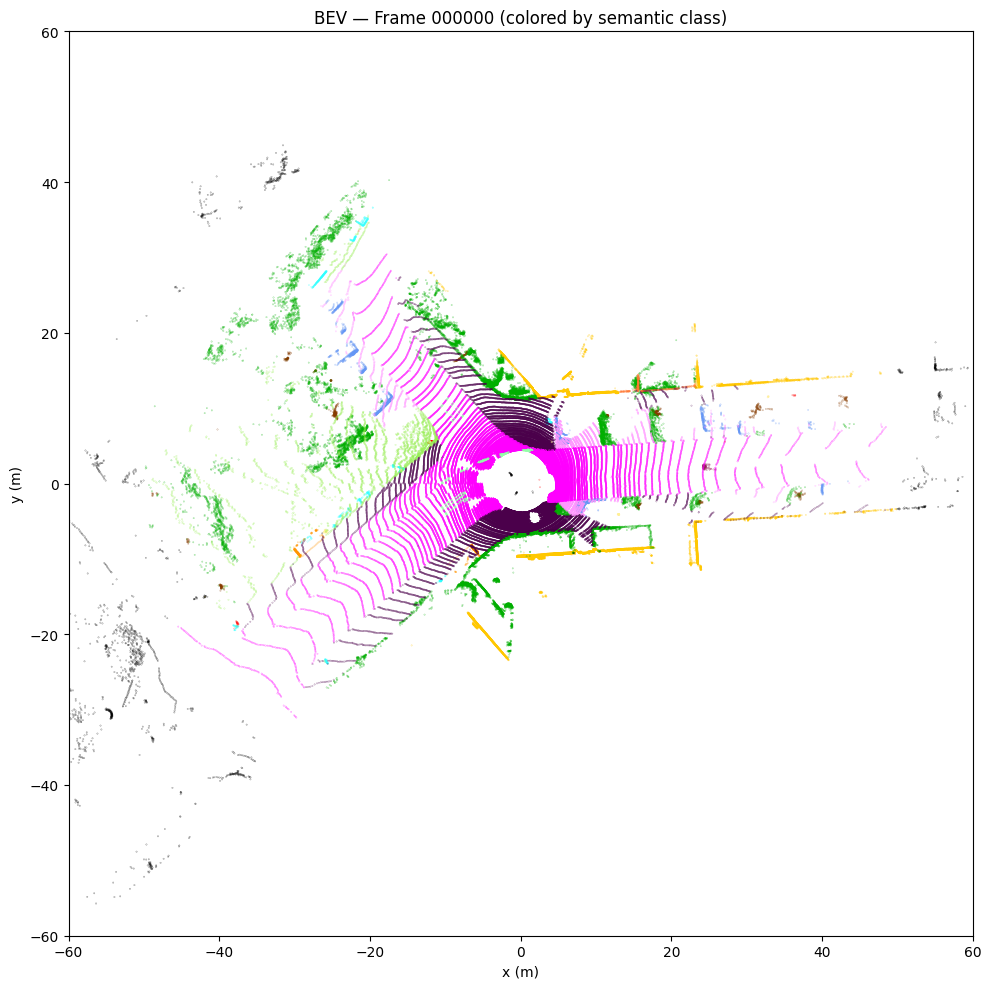

In [9]:
# BEV colored by semantic class
fig, ax = plt.subplots(figsize=(10, 10))

# Build color array from semantic labels
rgb = np.zeros((len(sem), 3))
for cls_id, color in LABEL_COLORS.items():
    mask = sem == cls_id
    rgb[mask] = np.array(color) / 255.0

ax.scatter(points[:, 0], points[:, 1], c=rgb, s=0.05, alpha=0.6)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("BEV — Frame 000000 (colored by semantic class)")
ax.set_aspect("equal")
ax.set_xlim(-60, 60)
ax.set_ylim(-60, 60)
plt.tight_layout()
plt.show()

## 4. Ego-Vehicle Poses, Calibration & Timestamps

- **`poses.txt`** — One 3×4 matrix per frame (SE(3) in the **camera frame**)
- **`calib.txt`** — Sensor calibration: camera projections (P0–P3) and LiDAR→camera transform (Tr)
- **`times.txt`** — Timestamp per frame (seconds since sequence start)

In [10]:
# Load poses, calibration, and timestamps for sequence 00
poses_path = os.path.join(DATA_ROOT, SEQ, "poses.txt")
calib_path = os.path.join(DATA_ROOT, SEQ, "calib.txt")
times_path = os.path.join(DATA_ROOT, SEQ, "times.txt")

poses = load_poses(poses_path)
calib = load_calib(calib_path)
times = load_times(times_path)
Tr = calib["Tr"]  # Velodyne-to-camera transformation

print(f"Number of poses: {len(poses)}")
print(f"Number of timestamps: {len(times)}")
print(f"\nFirst pose (frame 0) — should be near identity:")
print(poses[0])

# Extract translations (ego position over time)
translations = np.array([T[:3, 3] for T in poses])
print(f"\nTranslation range:")
print(f"  x: [{translations[:, 0].min():.1f}, {translations[:, 0].max():.1f}] m")
print(f"  y: [{translations[:, 1].min():.1f}, {translations[:, 1].max():.1f}] m")
print(f"  z: [{translations[:, 2].min():.1f}, {translations[:, 2].max():.1f}] m")
print(f"  Total path length: {np.sum(np.linalg.norm(np.diff(translations, axis=0), axis=1)):.1f} m")

Number of poses: 4541
Number of timestamps: 4541

First pose (frame 0) — should be near identity:
[[ 1.00000e+00  9.31323e-10 -3.27418e-11  0.00000e+00]
 [-9.31323e-10  1.00000e+00 -4.65661e-10  7.45058e-09]
 [ 1.09139e-11 -9.31323e-10  1.00000e+00  0.00000e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  1.00000e+00]]

Translation range:
  x: [-274.0, 290.6] m
  y: [-10.1, 4.6] m
  z: [-19.4, 479.0] m
  Total path length: 3712.3 m


### 4.1 Calibration (`calib.txt`)

Contains camera projection matrices (P0–P3) and the critical **Tr** matrix that transforms
LiDAR points into the camera coordinate frame. Since `poses.txt` is in the camera frame,
we need Tr to correctly place LiDAR points in the global frame:

```
p_global = T_pose @ Tr_velo_to_cam @ p_lidar
```

In [11]:
# Explore calib.txt
print("=== calib.txt contents ===")
for key, M in calib.items():
    print(f"\n{key}:")
    print(M)

# Highlight the Tr matrix
print("\n" + "=" * 50)
print("Tr (Velodyne -> Camera) is the key matrix for us.")
print("It rotates LiDAR coords (X=forward, Y=left, Z=up)")
print("into camera coords (X=right, Y=down, Z=forward).")
print(f"\nTr:\n{Tr}")

# Verify Tr rotation is valid
R_tr = Tr[:3, :3]
print(f"\nTr rotation det: {np.linalg.det(R_tr):.6f} (should be 1.0)")
print(f"Tr translation: {Tr[:3, 3]} (LiDAR offset from camera)")

=== calib.txt contents ===

P0:
[[718.856    0.     607.1928   0.    ]
 [  0.     718.856  185.2157   0.    ]
 [  0.       0.       1.       0.    ]
 [  0.       0.       0.       1.    ]]

P1:
[[ 718.856     0.      607.1928 -386.1448]
 [   0.      718.856   185.2157    0.    ]
 [   0.        0.        1.        0.    ]
 [   0.        0.        0.        1.    ]]

P2:
[[ 7.188560e+02  0.000000e+00  6.071928e+02  4.538225e+01]
 [ 0.000000e+00  7.188560e+02  1.852157e+02 -1.130887e-01]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  3.779761e-03]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]

P3:
[[ 7.188560e+02  0.000000e+00  6.071928e+02 -3.372877e+02]
 [ 0.000000e+00  7.188560e+02  1.852157e+02  2.369057e+00]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  4.915215e-03]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]

Tr:
[[ 4.27680239e-04 -9.99967248e-01 -8.08449168e-03 -1.19845993e-02]
 [-7.21062651e-03  8.08119847e-03 -9.99941316e-01 -5.40398473e-02]
 [ 9.99973

### 4.2 Timestamps (`times.txt`)

Real frame timestamps let us compute accurate speeds instead of assuming a fixed 10 Hz rate.

Number of timestamps: 4541
First 10 timestamps (seconds): [0.        0.1037359 0.2073381 0.3110752 0.4146917 0.5184302 0.6220448
 0.7257977 0.8294199 0.9331467]
Total duration: 470.6 seconds

Frame intervals:
  Mean: 103.65 ms (9.6 Hz)
  Std:  0.17 ms
  Min:  101.94 ms
  Max:  105.60 ms


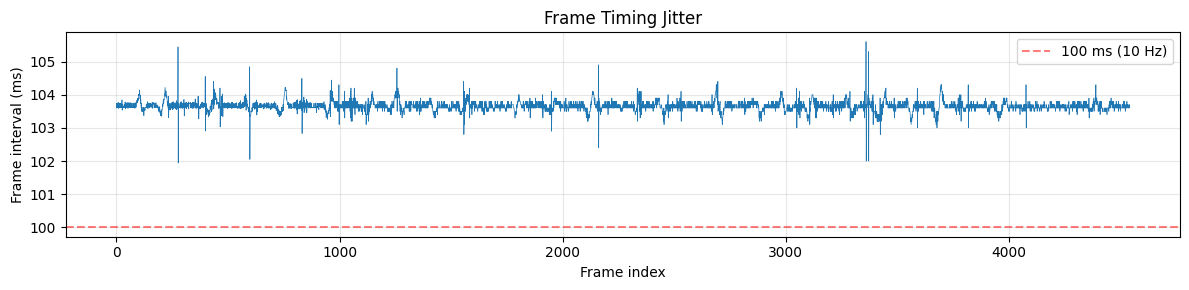

In [13]:
# Explore times.txt
print(f"Number of timestamps: {len(times)}")
print(f"First 10 timestamps (seconds): {times[:10]}")
print(f"Total duration: {times[-1] - times[0]:.1f} seconds")

# Frame intervals
dt_real = np.diff(times)
print(f"\nFrame intervals:")
print(f"  Mean: {dt_real.mean()*1000:.2f} ms ({1/dt_real.mean():.1f} Hz)")
print(f"  Std:  {dt_real.std()*1000:.2f} ms")
print(f"  Min:  {dt_real.min()*1000:.2f} ms")
print(f"  Max:  {dt_real.max()*1000:.2f} ms")

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(dt_real * 1000, linewidth=0.5)
ax.axhline(y=100, color="r", linestyle="--", alpha=0.5, label="100 ms (10 Hz)")
ax.set_xlabel("Frame index")
ax.set_ylabel("Frame interval (ms)")
ax.set_title("Frame Timing Jitter")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

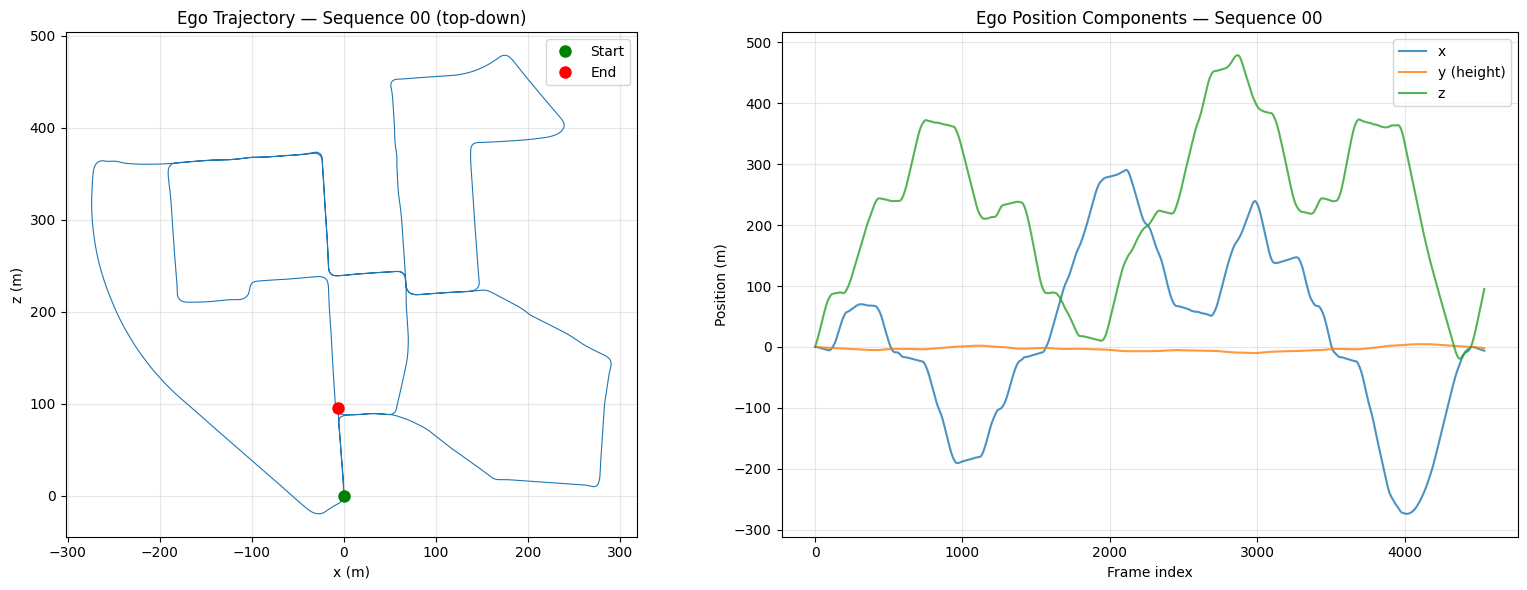

In [14]:
# 2D trajectory plot (x vs z in global frame — KITTI uses x-forward, z-right convention)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top-down trajectory
ax = axes[0]
ax.plot(translations[:, 0], translations[:, 2], linewidth=0.8)
ax.plot(translations[0, 0], translations[0, 2], "go", markersize=8, label="Start")
ax.plot(translations[-1, 0], translations[-1, 2], "ro", markersize=8, label="End")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_title(f"Ego Trajectory — Sequence {SEQ} (top-down)")
ax.set_aspect("equal")
ax.legend()
ax.grid(True, alpha=0.3)

# x, y, z over frame index
ax = axes[1]
frames = np.arange(len(translations))
ax.plot(frames, translations[:, 0], label="x", alpha=0.8)
ax.plot(frames, translations[:, 1], label="y (height)", alpha=0.8)
ax.plot(frames, translations[:, 2], label="z", alpha=0.8)
ax.set_xlabel("Frame index")
ax.set_ylabel("Position (m)")
ax.set_title(f"Ego Position Components — Sequence {SEQ}")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

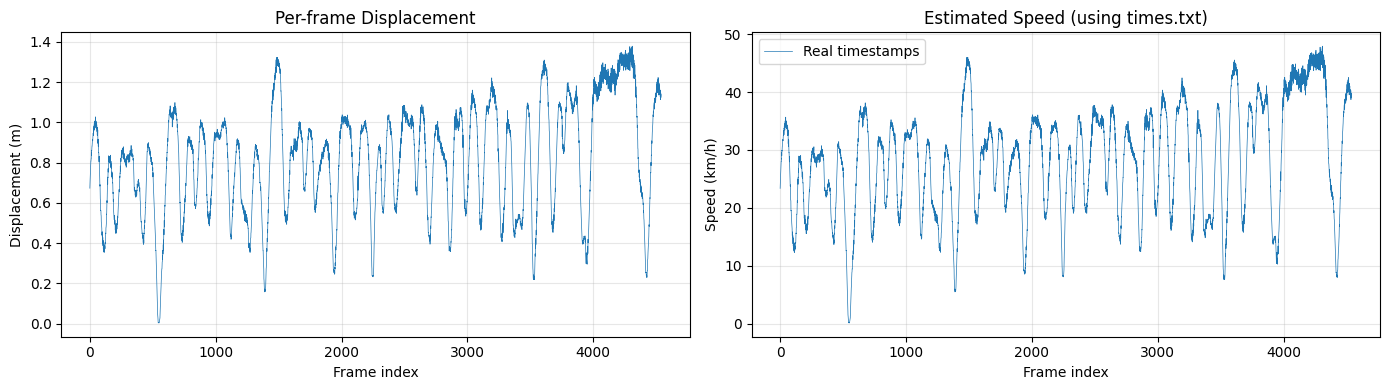

Speed stats: mean=28.4 km/h, max=47.9 km/h, min=0.12 km/h


In [15]:
# Per-frame displacement and speed (using real timestamps)
displacements = np.linalg.norm(np.diff(translations, axis=0), axis=1)
dt_real = np.diff(times)

# Guard against zero dt
dt_safe = np.where(dt_real > 0, dt_real, 0.1)
speeds = displacements / dt_safe  # m/s
speeds_kmh = speeds * 3.6  # km/h

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(displacements, linewidth=0.5)
ax.set_xlabel("Frame index")
ax.set_ylabel("Displacement (m)")
ax.set_title("Per-frame Displacement")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(speeds_kmh, linewidth=0.5, label="Real timestamps")
ax.set_xlabel("Frame index")
ax.set_ylabel("Speed (km/h)")
ax.set_title("Estimated Speed (using times.txt)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Speed stats: mean={speeds_kmh.mean():.1f} km/h, max={speeds_kmh.max():.1f} km/h, "
      f"min={speeds_kmh.min():.2f} km/h")

In [16]:
# Verify rotation matrices are valid (orthogonal, det=1)
ortho_errors = []
det_values = []
for T in poses:
    R = T[:3, :3]
    ortho_err = np.linalg.norm(R @ R.T - np.eye(3))
    ortho_errors.append(ortho_err)
    det_values.append(np.linalg.det(R))

print("Rotation matrix validation:")
print(
    f"  Orthogonality error (||R·Rᵀ - I||): max={max(ortho_errors):.2e}, mean={np.mean(ortho_errors):.2e}"
)
print(
    f"  Determinant: min={min(det_values):.6f}, max={max(det_values):.6f} (should be 1.0)"
)

Rotation matrix validation:
  Orthogonality error (||R·Rᵀ - I||): max=2.29e-06, mean=1.07e-06
  Determinant: min=0.999999, max=1.000002 (should be 1.0)


## 5. Sequence-Level Exploration

Examine the dataset across all sequences and across frames within a sequence.


In [17]:
# Survey all sequences
print(
    f"{'Seq':<5} {'Velodyne':>10} {'Labels':>10} {'Poses':>8} {'Calib':>8} {'Times':>8}"
)
print("-" * 55)

seq_info = []
for seq_dir in sorted(glob.glob(os.path.join(DATA_ROOT, "*"))):
    seq_id = os.path.basename(seq_dir)
    vel_dir = os.path.join(seq_dir, "velodyne")
    lab_dir = os.path.join(seq_dir, "labels")
    poses_file = os.path.join(seq_dir, "poses.txt")
    calib_file = os.path.join(seq_dir, "calib.txt")
    times_file = os.path.join(seq_dir, "times.txt")

    n_vel = (
        len(glob.glob(os.path.join(vel_dir, "*.bin"))) if os.path.isdir(vel_dir) else 0
    )
    n_lab = (
        len(glob.glob(os.path.join(lab_dir, "*.label")))
        if os.path.isdir(lab_dir)
        else 0
    )
    has_poses = os.path.isfile(poses_file)
    has_calib = os.path.isfile(calib_file)
    has_times = os.path.isfile(times_file)

    seq_info.append(
        {
            "seq": seq_id,
            "n_vel": n_vel,
            "n_lab": n_lab,
            "has_poses": has_poses,
            "has_calib": has_calib,
            "has_times": has_times,
        }
    )

    print(
        f"{seq_id:<5} {n_vel:>10} {n_lab:>10} {'yes' if has_poses else '-':>8} "
        f"{'yes' if has_calib else '-':>8} {'yes' if has_times else '-':>8}"
    )

Seq     Velodyne     Labels    Poses    Calib    Times
-------------------------------------------------------
00          4541       4541      yes      yes      yes
01          1101       1101      yes      yes      yes
02             0       4661      yes      yes      yes
03             0        801      yes      yes      yes
04             0        271      yes      yes      yes
05             0       2761      yes      yes      yes
06             0       1101      yes      yes      yes
07             0       1101      yes      yes      yes
08             0       4071      yes      yes      yes
09             0       1591      yes      yes      yes
10             0       1201      yes      yes      yes
11             0          0      yes      yes      yes
12             0          0      yes      yes      yes
13             0          0      yes      yes      yes
14             0          0      yes      yes      yes
15             0          0      yes      yes      yes
16       

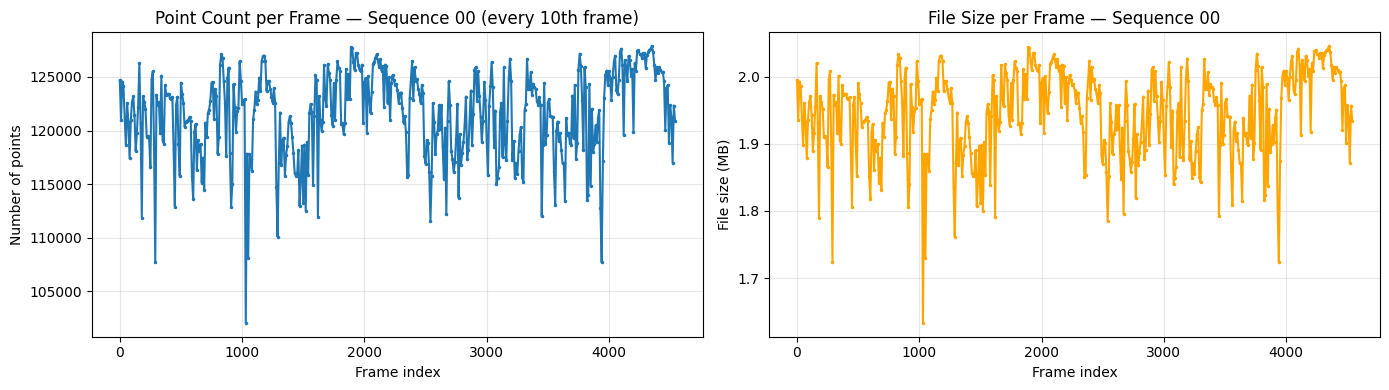

Point count: min=102,066, max=127,864, mean=121,540, std=4,014


In [18]:
# Point count variation across frames in sequence 00
bin_paths = sorted(glob.glob(os.path.join(DATA_ROOT, SEQ, "velodyne", "*.bin")))

# Sample every 10th frame to keep it fast
sample_indices = list(range(0, len(bin_paths), 10))
point_counts = []
file_sizes = []

for idx in sample_indices:
    pts = load_bin(bin_paths[idx])
    point_counts.append(len(pts))
    file_sizes.append(os.path.getsize(bin_paths[idx]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(sample_indices, point_counts, ".-", markersize=3)
ax.set_xlabel("Frame index")
ax.set_ylabel("Number of points")
ax.set_title(f"Point Count per Frame — Sequence {SEQ} (every 10th frame)")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(
    sample_indices, [s / 1e6 for s in file_sizes], ".-", markersize=3, color="orange"
)
ax.set_xlabel("Frame index")
ax.set_ylabel("File size (MB)")
ax.set_title(f"File Size per Frame — Sequence {SEQ}")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(
    f"Point count: min={min(point_counts):,}, max={max(point_counts):,}, "
    f"mean={np.mean(point_counts):,.0f}, std={np.std(point_counts):,.0f}"
)

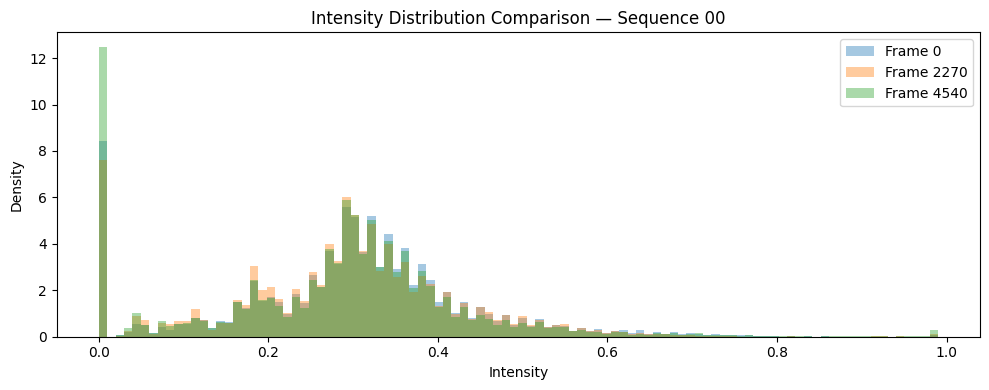

In [19]:
# Compare intensity distributions: early, mid, late frames
frame_indices = [0, len(bin_paths) // 2, len(bin_paths) - 1]
fig, ax = plt.subplots(figsize=(10, 4))

for idx in frame_indices:
    pts = load_bin(bin_paths[idx])
    ax.hist(pts[:, 3], bins=100, alpha=0.4, label=f"Frame {idx}", density=True)

ax.set_xlabel("Intensity")
ax.set_ylabel("Density")
ax.set_title(f"Intensity Distribution Comparison — Sequence {SEQ}")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Data Relationships

How the three data files relate to each other.


### 6.1 bin ↔ label: 1:1 Point Correspondence

Every `.bin` point has exactly one `.label` entry. We can overlay semantic labels directly onto the point cloud.


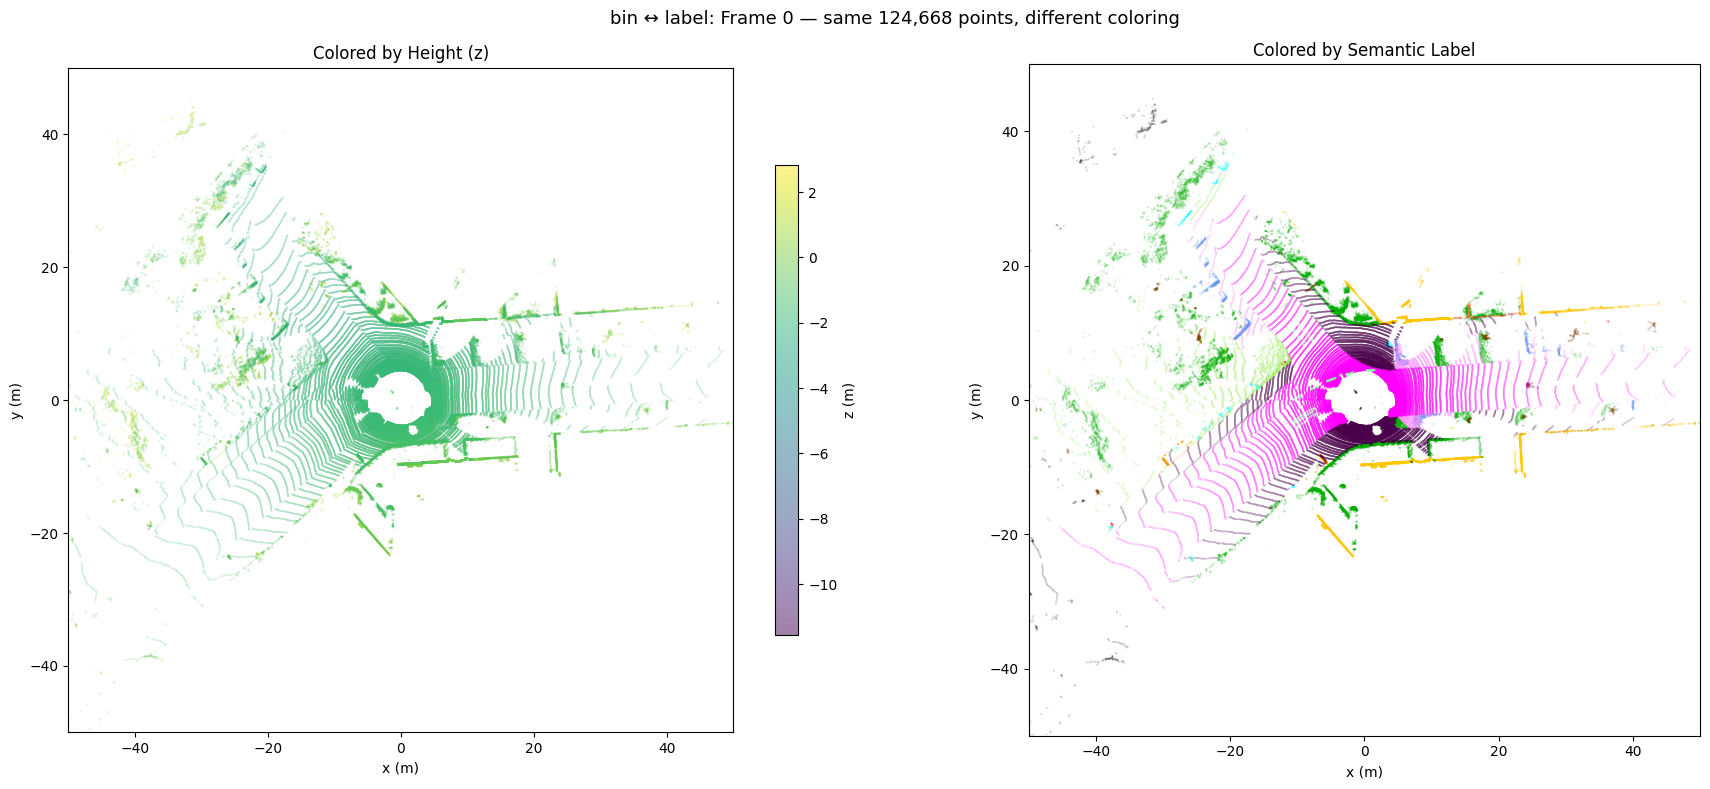

In [20]:
# Side-by-side: raw height vs semantic labels
frame_idx = 0
pts = load_bin(bin_paths[frame_idx])
label_paths = sorted(glob.glob(os.path.join(DATA_ROOT, SEQ, "labels", "*.label")))
sem_f, inst_f = load_label(label_paths[frame_idx])

assert len(pts) == len(sem_f), f"Mismatch! bin={len(pts)}, label={len(sem_f)}"

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: colored by height
ax = axes[0]
sc = ax.scatter(pts[:, 0], pts[:, 1], c=pts[:, 2], cmap="viridis", s=0.02, alpha=0.5)
plt.colorbar(sc, ax=ax, label="z (m)", shrink=0.7)
ax.set_title("Colored by Height (z)")
ax.set_aspect("equal")
ax.set_xlim(-50, 50)
ax.set_ylim(-50, 50)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

# Right: colored by semantic class
ax = axes[1]
rgb = np.zeros((len(sem_f), 3))
for cls_id, color in LABEL_COLORS.items():
    mask = sem_f == cls_id
    rgb[mask] = np.array(color) / 255.0
ax.scatter(pts[:, 0], pts[:, 1], c=rgb, s=0.02, alpha=0.5)
ax.set_title("Colored by Semantic Label")
ax.set_aspect("equal")
ax.set_xlim(-50, 50)
ax.set_ylim(-50, 50)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

plt.suptitle(
    f"bin ↔ label: Frame {frame_idx} — same {len(pts):,} points, different coloring",
    fontsize=13,
)
plt.tight_layout()
plt.show()

### 6.2 bin ↔ poses: Local to Global Transformation

Each frame's points are in the **sensor's local frame**. The pose matrix transforms them to a **global coordinate system**. This lets us align points from different frames.


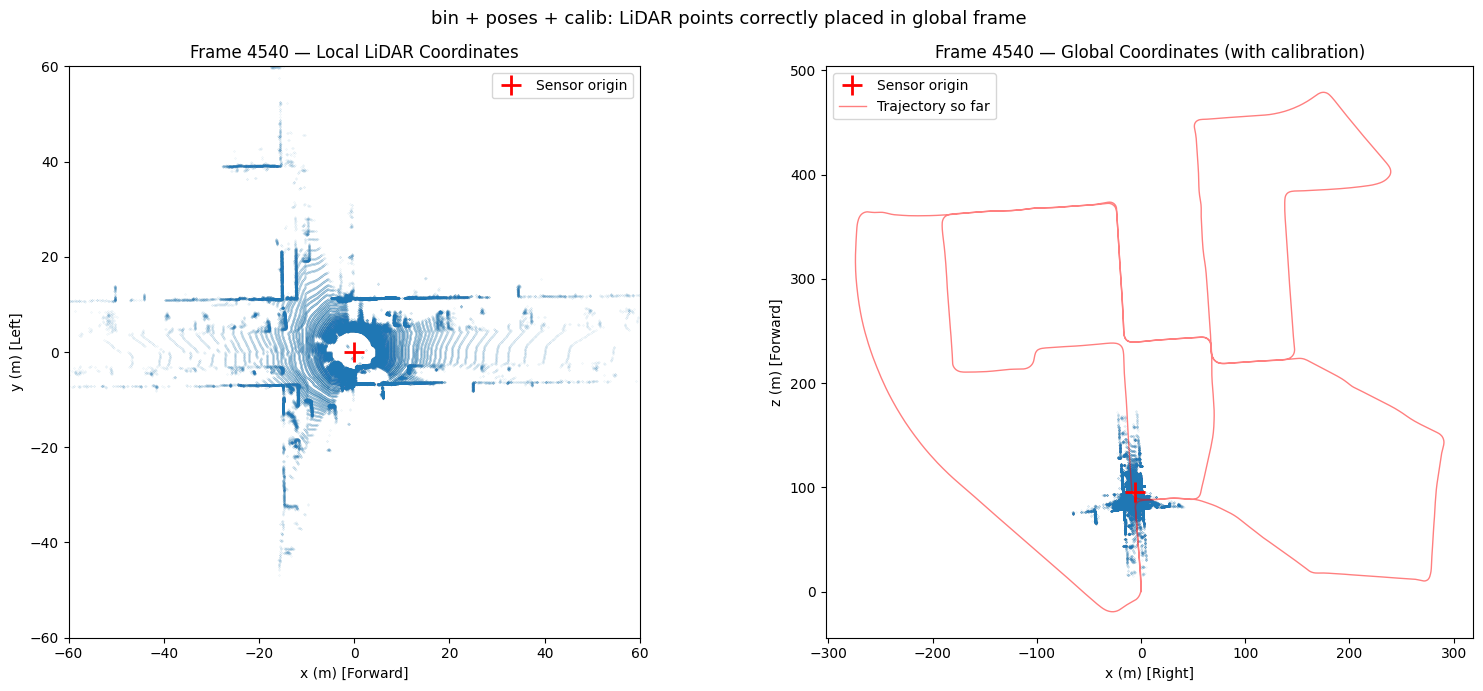

In [26]:
# Transform a single frame from local to global coordinates
frame_idx = len(poses)-1  # pick a frame where the car has moved significantly
pts_local = load_bin(bin_paths[frame_idx])[:, :3]
T = poses[frame_idx]

# Correct transformation chain: pose (camera frame) @ Tr (velo->cam) @ point (LiDAR)
T_total = T @ Tr
pts_global = (T_total[:3, :3] @ pts_local.T + T_total[:3, 3:4]).T

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.scatter(pts_local[:, 0], pts_local[:, 1], s=0.02, alpha=0.3)
ax.plot(0, 0, "r+", markersize=15, markeredgewidth=2, label="Sensor origin")
ax.set_title(f"Frame {frame_idx} — Local LiDAR Coordinates")
ax.set_xlabel("x (m) [Forward]")
ax.set_ylabel("y (m) [Left]")
ax.set_aspect("equal")
ax.legend()
ax.set_xlim(-60, 60)
ax.set_ylim(-60, 60)

ax = axes[1]
ax.scatter(pts_global[:, 0], pts_global[:, 2], s=0.02, alpha=0.3)
# Sensor origin in global frame: X vs Z
ax.plot(T[0, 3], T[2, 3], "r+", markersize=15, markeredgewidth=2, label="Sensor origin")
ax.plot(
    translations[:frame_idx + 1, 0],
    translations[:frame_idx + 1, 2],
    "r-", linewidth=1, alpha=0.5, label="Trajectory so far",
)
ax.set_title(f"Frame {frame_idx} — Global Coordinates (with calibration)")
ax.set_xlabel("x (m) [Right]")
ax.set_ylabel("z (m) [Forward]")
ax.set_aspect("equal")
ax.legend()

plt.suptitle("bin + poses + calib: LiDAR points correctly placed in global frame", fontsize=13)
plt.tight_layout()
plt.show()

### 6.3 Multi-Frame Accumulation (poses + bin)

By transforming multiple frames into the global coordinate system, we can build a dense point cloud map. This is the basis for point cloud accumulation in the pipeline.


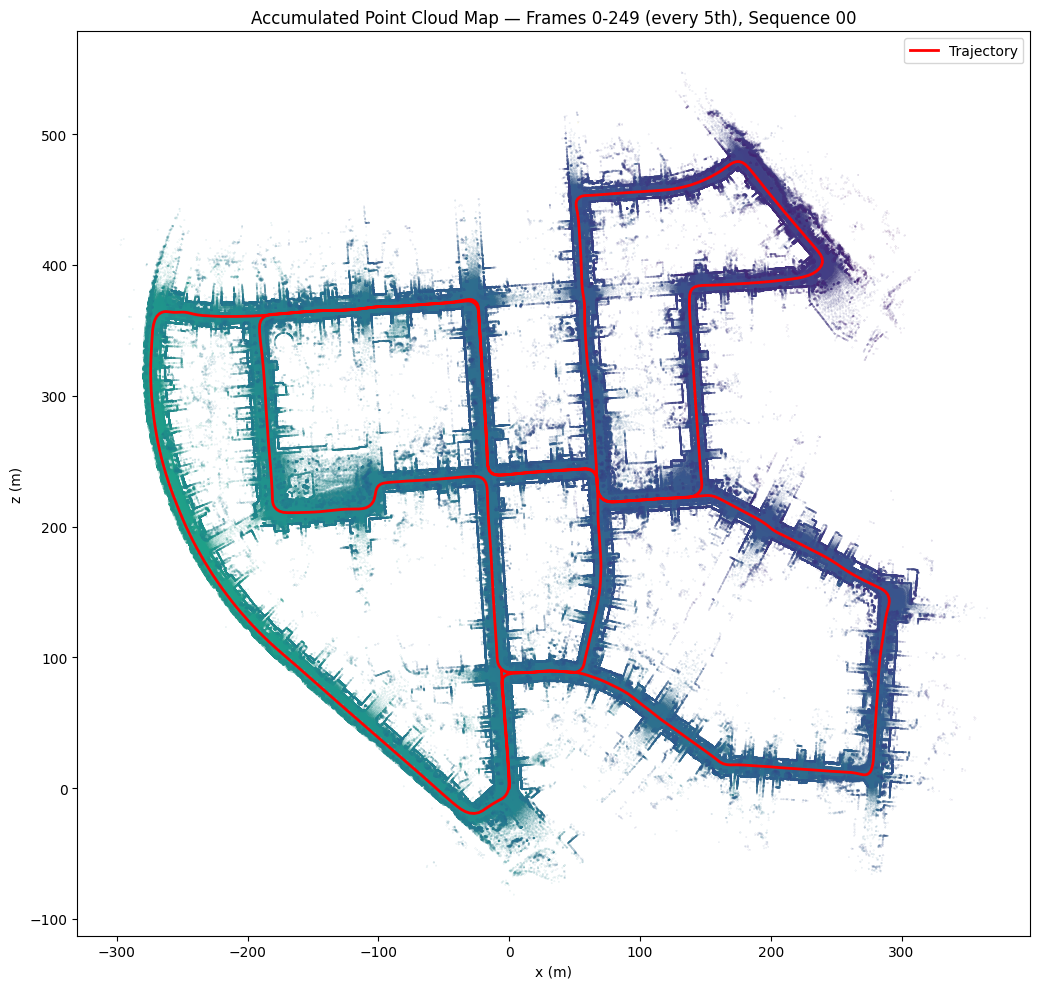

Accumulated 4,635,590 points from 908 frames


In [ ]:
# Accumulate frames (every 5th frame to keep it manageable)
accumulate_indices = list(range(0, len(poses)-1, 5))
all_global_pts = []

for idx in accumulate_indices:
    pts_local = load_bin(bin_paths[idx])[:, :3]
    T_total = poses[idx] @ Tr  # pose @ velo-to-cam calibration
    pts_global = (T_total[:3, :3] @ pts_local.T + T_total[:3, 3:4]).T
    # Subsample to keep plot responsive
    stride = max(1, len(pts_global) // 5000)
    all_global_pts.append(pts_global[::stride])

accumulated = np.vstack(all_global_pts)

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(
    accumulated[:, 0], accumulated[:, 2],
    c=accumulated[:, 1], cmap="viridis", s=0.02, alpha=0.3,
)
ax.plot(
    translations[accumulate_indices, 0],
    translations[accumulate_indices, 2],
    "r-", linewidth=2, label="Trajectory",
)
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_title(f"Accumulated Point Cloud Map — Frames (every 5th), Sequence {SEQ}")
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Accumulated {len(accumulated):,} points from {len(accumulate_indices)} frames")

### 6.4 label ↔ poses: Object Density Along Trajectory

How does the number of detected instances vary as the vehicle moves through the scene?


In [ ]:
# Track instance counts along the sequence (sample every 20th frame)
sample_frames = list(range(0, min(len(label_paths), len(bin_paths)), 20))
car_counts = []
person_counts = []
total_thing_counts = []

for idx in sample_frames:
    sem_s, inst_s = load_label(label_paths[idx])
    # Count unique instances per category
    car_mask = np.isin(sem_s, [10, 252])  # car + moving-car
    person_mask = np.isin(sem_s, [30, 254])  # person + moving-person
    thing_mask = np.isin(sem_s, list(THING_CLASSES))

    car_inst = np.unique(inst_s[car_mask])
    car_inst = car_inst[car_inst > 0]
    person_inst = np.unique(inst_s[person_mask])
    person_inst = person_inst[person_inst > 0]
    thing_inst = np.unique(inst_s[thing_mask])
    thing_inst = thing_inst[thing_inst > 0]

    car_counts.append(len(car_inst))
    person_counts.append(len(person_inst))
    total_thing_counts.append(len(thing_inst))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(sample_frames, car_counts, ".-", label="Cars", markersize=4)
ax.plot(sample_frames, person_counts, ".-", label="Persons", markersize=4)
ax.plot(
    sample_frames, total_thing_counts, ".-", label="All things", markersize=4, alpha=0.6
)
ax.set_xlabel("Frame index")
ax.set_ylabel("Number of instances")
ax.set_title(f"Instance Count Over Time — Sequence {SEQ}")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot instance density on trajectory
ax = axes[1]
traj_x = translations[sample_frames, 0]
traj_z = translations[sample_frames, 2]
sc = ax.scatter(traj_x, traj_z, c=total_thing_counts, cmap="hot", s=20, zorder=5)
ax.plot(translations[:, 0], translations[:, 2], "gray", linewidth=0.5, alpha=0.5)
plt.colorbar(sc, ax=ax, label="Thing instances")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_title("Object Density Along Trajectory")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

### 6.5 All Three Together: Accumulated Labeled Point Cloud

Combine consecutive frames into a single global point cloud with semantic labels — showing how all three files work together.


In [ ]:
# Accumulate 5 consecutive frames with semantic labels in global frame
start_frame = 100
n_frames = 5
all_pts = []
all_rgb = []

for i in range(n_frames):
    idx = start_frame + i
    pts_local = load_bin(bin_paths[idx])[:, :3]
    sem_i, _ = load_label(label_paths[idx])
    T_total = poses[idx] @ Tr  # pose @ velo-to-cam calibration

    # Transform to global
    pts_global = (T_total[:3, :3] @ pts_local.T + T_total[:3, 3:4]).T

    # Build RGB from semantic labels
    rgb = np.zeros((len(sem_i), 3))
    for cls_id, color in LABEL_COLORS.items():
        mask = sem_i == cls_id
        rgb[mask] = np.array(color) / 255.0

    # Subsample for plotting
    stride = max(1, len(pts_global) // 10000)
    all_pts.append(pts_global[::stride])
    all_rgb.append(rgb[::stride])

acc_pts = np.vstack(all_pts)
acc_rgb = np.vstack(all_rgb)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# BEV colored by semantic class (X vs Z)
ax = axes[0]
ax.scatter(acc_pts[:, 0], acc_pts[:, 2], c=acc_rgb, s=0.05, alpha=0.4)
# Mark ego positions
for i in range(n_frames):
    fidx = start_frame + i
    ax.plot(translations[fidx, 0], translations[fidx, 2], "k^", markersize=6)
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_title(
    f"BEV — Frames {start_frame}-{start_frame+n_frames-1} (semantic labels, global frame)"
)
ax.set_aspect("equal")

# Side view (X vs Y)
ax = axes[1]
ax.scatter(acc_pts[:, 0], acc_pts[:, 1], c=acc_rgb, s=0.05, alpha=0.4)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (height, m)")
ax.set_title("Side View — same frames")
ax.set_ylim(-5, 10)

plt.suptitle(
    "bin + label + poses + calib: Accumulated labeled point cloud in global frame", fontsize=13
)
plt.tight_layout()
plt.show()

print(f"Accumulated {len(acc_pts):,} points from frames {start_frame}\u2013{start_frame+n_frames-1}")

## 7. Cross-File Consistency Checks

Verify that `.bin`, `.label`, and `poses.txt` are consistent within each sequence.


In [ ]:
# Check frame count consistency across all sequences with data
print("Cross-file consistency checks:")
print(f"{'Seq':<5} {'Velodyne':>10} {'Labels':>10} {'Poses':>10} {'Match':>8}")
print("-" * 48)

for info in seq_info:
    seq_id = info["seq"]
    n_vel = info["n_vel"]
    n_lab = info["n_lab"]

    # Count poses
    poses_file = os.path.join(DATA_ROOT, seq_id, "poses.txt")
    n_poses = 0
    if os.path.isfile(poses_file):
        with open(poses_file) as f:
            n_poses = sum(1 for _ in f)

    # Check match
    counts = [c for c in [n_vel, n_lab, n_poses] if c > 0]
    match = "OK" if len(set(counts)) <= 1 else "MISMATCH"

    print(f"{seq_id:<5} {n_vel:>10} {n_lab:>10} {n_poses:>10} {match:>8}")

In [ ]:
# Verify per-point consistency: bin point count == label count (spot-check 10 frames)
print("Per-point bin↔label consistency (sequence 00, 10 random frames):")
rng = np.random.default_rng(42)
check_indices = sorted(
    rng.choice(len(bin_paths), size=min(10, len(bin_paths)), replace=False)
)

all_ok = True
for idx in check_indices:
    n_pts = len(load_bin(bin_paths[idx]))
    n_lab = len(np.fromfile(label_paths[idx], dtype=np.uint32))
    ok = n_pts == n_lab
    if not ok:
        all_ok = False
    print(
        f"  Frame {idx:>5}: bin={n_pts:>7,} pts, label={n_lab:>7,} pts  {'OK' if ok else 'MISMATCH!'}"
    )

print(f"\nAll checked frames consistent: {all_ok}")